# Introduction

*Tensor decoupling* is a methodology for finding decoupled representations of multivariate functions. See [this paper](https://arxiv.org/abs/1410.4060) for more background information.

Formally, we look for a mapping
$$\mathbf{f}(\mathbf{x}) \to \mathbf{Wg}(\mathbf{V}^T \mathbf{x}),$$
where
- $\mathbf{f}: \mathbb{R}^m \to \mathbb{R}^n$,
- $\mathbf{W} \in \mathbb{R}^{n \times r}$,
- $\mathbf{V} \in \mathbb{R}^{m \times r}$,
- $\mathbf{g}: \mathbb{R}^{r} \to \mathbb{R}^r$ such that $\mathbf{g}(\mathbf{u}) = [g_1(u_1)\; g_2(u_2)\; \dots \; g_r(u_r)]^T$.

The integer $r > 0$ is called *rank*.

<center><img src="images/decoupling.png" width=700></center>

*Untangle* is a library that implements algorithms and methods to find such representations.

Let's begin by importing the necessary libraries and defining our target function. For simplicity, we will use a simple polynomial, although tensor decoupling algorithms can deal with more complex functions.

In [1]:
import jax, jax.numpy as jnp # we use jax because we need autodiff

key = jax.random.key(42)
key_test = jax.random.key(43)

def target(x):
    x1, x2 = x
    return jnp.array([
        2*x1**3 + x2**2 + x1*x2 + 2,
        x2**3 + (x1+x2)**2 - x1 - 1,
    ])

# let's look at an example input/output
target(jnp.array([2, 3]))

Array([33, 49], dtype=int32)

To find the decoupled representation, we need to first collect information about our target, namely outputs and Jacobians (stacked into a 3d tensor). We can use the `collect_information` function to do that for us. By default, the sampling range is $[0, 1]$ (but it can be changed by passing `minval` and `maxval`).

In [2]:
from untangle.utils import collect_information

N = 30 # number of data points to collect

X, Y, J = collect_information(target, N, key) # returns inputs, outputs and stacked Jacobian tensor
X.shape, Y.shape, J.shape

((30, 2), (30, 2), (2, 2, 30))

We can now run our tensor decoupling algorithm. Every decoupling algorithm returns a `Decoupling` object, which is also callable. We also get an `error` which corresponds to the CP decomposition error.

In [3]:
from untangle.algorithm import basic_decoupling

rank = 9

decoupling, error = basic_decoupling(X, Y, J, rank, key=key)
print(f'CPD error: {error:.5f}')

|CPD|:   2%|▉                                            | 2/100 [00:00<00:24,  3.98it/s, (Early stopping after 3 iterations.)]


CPD error: 0.00000


It seems like our algorithm converged very quickly (< 10 iterations)!

Let's look at an example input/output.

In [4]:
y_decoupling = decoupling(X[0])
y_target = target(X[0])

print(f'Example target output:     {y_target}')
print(f'Example decoupling output: {y_decoupling}')

Example target output:     [3.0277915  0.19084918]
Example decoupling output: [3.0277846  0.19084635]


That looks quite good, we can use the `function_error` function to get the per-output error. 

In [5]:
from untangle.utils import function_error

function_error(target, decoupling, key=key_test)

Array([0.00093611, 0.00033548], dtype=float32)

Less than 1% error on each output, great!

Finally, we can take a look at our internal functions $g_1\;\dots\;g_r$.

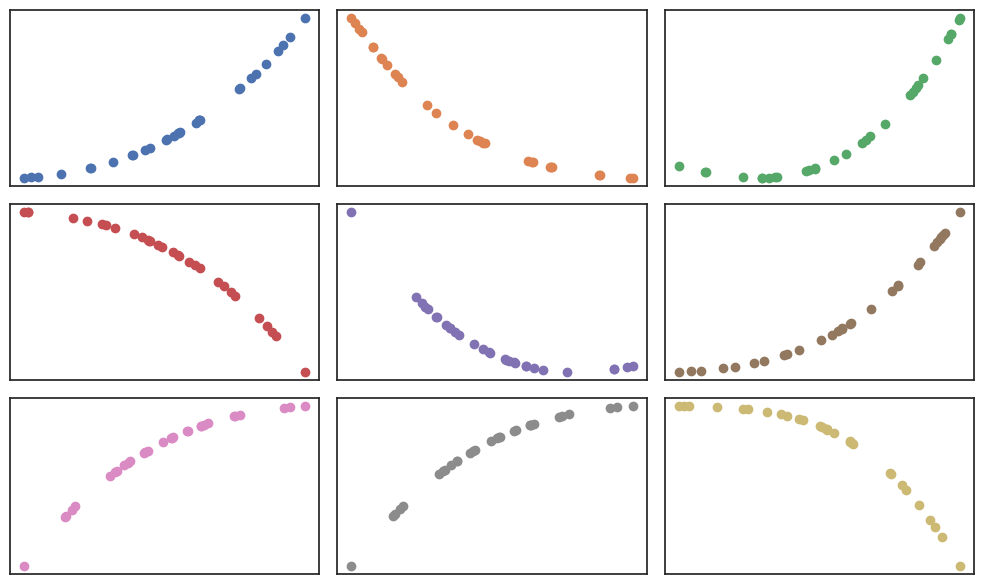

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook', 'white')
colors = sns.color_palette()

Z = X @ decoupling.V # internals inputs
Y = []

for z in Z:
    y = decoupling.internals(z)
    Y.append(y)

Y = jnp.stack(Y)

fig, ax = plt.subplots(3, 3, figsize=(10, 6))
for r, a in enumerate(ax.flatten()): 
    a.set_xticks([]); a.set_yticks([])
    a.scatter(Z[:, r], Y[:, r], color=colors[r])

plt.tight_layout(); plt.show()